<a href="https://colab.research.google.com/github/ShorouqTelfah/Automated-methods-to-detect-pneumonia-diseases-from-medical-images/blob/main/kaggle_vindr_mammo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Step 1: Mount Google Drive
from google.colab import drive

drive.mount('/content/drive')


Mounted at /content/drive


In [2]:
# --- Step 1: Import libraries ---
import pandas as pd
from sklearn.model_selection import train_test_split
import os, shutil

In [3]:
# --- Step 2: Define paths ---

annotations_path = "/content/drive/My Drive/vindr-mammo/breast-level_annotations.csv"
metadata_path = "/content/drive/My Drive/vindr-mammo/metadata.csv"


In [4]:
# --- Step 3: Load both files ---
breast_annotations = pd.read_csv(annotations_path)
metadata_df = pd.read_csv(metadata_path)

print("Annotations shape:", breast_annotations.shape)
print("Metadata shape:", metadata_df.shape)


Annotations shape: (20000, 10)
Metadata shape: (20000, 21)


In [5]:
# --- Check columns in annotations file ---
print("\n📘 Columns in breast_annotations:")
print(breast_annotations.columns.tolist())
# --- Check columns in metadata file ---
print("\n📗 Columns in metadata_df:")
print(metadata_df.columns.tolist())


📘 Columns in breast_annotations:
['study_id', 'series_id', 'image_id', 'laterality', 'view_position', 'height', 'width', 'breast_birads', 'breast_density', 'split']

📗 Columns in metadata_df:
['SOP Instance UID', 'Series Instance UID', 'SOP Instance UID.1', "Patient's Age", 'View Position', 'Image Laterality', 'Photometric Interpretation', 'Rows', 'Columns', 'Imager Pixel Spacing', 'Pixel Spacing', 'Pixel Padding Value', 'Pixel Padding Range Limit', 'Window Center', 'Window Width', 'Rescale Intercept', 'Rescale Slope', 'Rescale Type', 'Window Center & Width Explanation', 'Manufacturer', "Manufacturer's Model Name"]


In [6]:

(metadata_df["SOP Instance UID"] == metadata_df["SOP Instance UID.1"]).all()

np.True_

In [7]:
# --- Step 1: Prepare metadata_df for merge ---
metadata_df = metadata_df.rename(columns={"SOP Instance UID": "image_id"})

In [8]:
# Drop the duplicate UID column if present
if "SOP Instance UID.1" in metadata_df.columns:
    metadata_df = metadata_df.drop(columns=["SOP Instance UID.1"])


In [9]:
# --- Step 2: Merge both files on 'image_id' ---
merged_df = pd.merge(
    breast_annotations,
    metadata_df,
    on="image_id",
    how="inner"  # 'inner' keeps only images present in both files
)

In [10]:
# --- Step 3: Verify ---
print("✅ Merged DataFrame shape:", merged_df.shape)
print("✅ Columns in merged_df:")
print(merged_df.columns.tolist())
print("\nSample rows:")
print(merged_df.head())

✅ Merged DataFrame shape: (20000, 29)
✅ Columns in merged_df:
['study_id', 'series_id', 'image_id', 'laterality', 'view_position', 'height', 'width', 'breast_birads', 'breast_density', 'split', 'Series Instance UID', "Patient's Age", 'View Position', 'Image Laterality', 'Photometric Interpretation', 'Rows', 'Columns', 'Imager Pixel Spacing', 'Pixel Spacing', 'Pixel Padding Value', 'Pixel Padding Range Limit', 'Window Center', 'Window Width', 'Rescale Intercept', 'Rescale Slope', 'Rescale Type', 'Window Center & Width Explanation', 'Manufacturer', "Manufacturer's Model Name"]

Sample rows:
                           study_id                         series_id  \
0  b8d273e8601f348d3664778dae0e7e0b  b36517b9cbbcfd286a7ae04f643af97a   
1  b8d273e8601f348d3664778dae0e7e0b  b36517b9cbbcfd286a7ae04f643af97a   
2  b8d273e8601f348d3664778dae0e7e0b  b36517b9cbbcfd286a7ae04f643af97a   
3  b8d273e8601f348d3664778dae0e7e0b  b36517b9cbbcfd286a7ae04f643af97a   
4  8269f5971eaca3e5d3772d1796e6bd7a  d9

In [11]:
merged_df.shape


(20000, 29)

In [12]:
merged_df.columns

Index(['study_id', 'series_id', 'image_id', 'laterality', 'view_position',
       'height', 'width', 'breast_birads', 'breast_density', 'split',
       'Series Instance UID', 'Patient's Age', 'View Position',
       'Image Laterality', 'Photometric Interpretation', 'Rows', 'Columns',
       'Imager Pixel Spacing', 'Pixel Spacing', 'Pixel Padding Value',
       'Pixel Padding Range Limit', 'Window Center', 'Window Width',
       'Rescale Intercept', 'Rescale Slope', 'Rescale Type',
       'Window Center & Width Explanation', 'Manufacturer',
       'Manufacturer's Model Name'],
      dtype='object')

In [13]:
merged_df["Patient's Age"].apply(type).value_counts()


,count
Patient's Age,
<class 'str'>,17740
<class 'float'>,2260


In [14]:
merged_df["Patient's Age"].isna().any()


np.True_

In [15]:
merged_df["Patient's Age"].isna().sum()


np.int64(2260)

In [16]:
total_missing = merged_df["Patient's Age"].isna().sum()
percent_missing = merged_df["Patient's Age"].isna().mean() * 100

print(f"Missing rows: {total_missing} ({percent_missing:.2f}%)")


Missing rows: 2260 (11.30%)


In [17]:
merged_df["Patient's Age"].dtype


dtype('O')

In [19]:
# Convert to numeric, extracting digits from strings, but keep NaN for missing values
merged_df["Patient's Age"] = (
    merged_df["Patient's Age"]
    .astype(str)          # ensure all values are strings
    .str.extract(r"(\d+)")  # extract digits only
    .astype(float)        # convert to numeric
)

# Check the result
print(merged_df["Patient's Age"].dtype)            # should be float64
print(merged_df["Patient's Age"].isna().sum())     # number of missing values
print(merged_df["Patient's Age"].apply(type).value_counts())


float64
2260
Patient's Age
<class 'float'>    20000
Name: count, dtype: int64


In [20]:
merged_df["Patient's Age"].describe()


,Patient's Age
count,17740.000000
mean,44.119053
std,11.698422
min,0.000000
25%,38.000000
50%,45.000000
75%,51.000000
max,88.000000


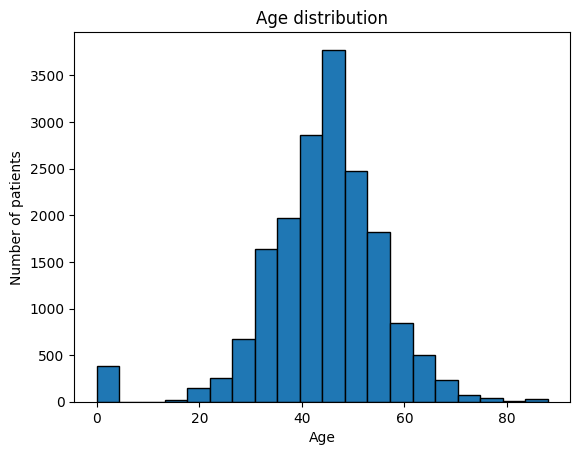

In [21]:
import matplotlib.pyplot as plt

plt.hist(merged_df["Patient's Age"].dropna(), bins=20, edgecolor='k')
plt.xlabel("Age")
plt.ylabel("Number of patients")
plt.title("Age distribution")
plt.show()


In [22]:
Q1 = merged_df["Patient's Age"].quantile(0.25)
Q3 = merged_df["Patient's Age"].quantile(0.75)
IQR = Q3 - Q1

# Define outlier boundaries
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = merged_df[(merged_df["Patient's Age"] < lower_bound) |
                     (merged_df["Patient's Age"] > upper_bound)]

print(f"Number of outliers: {outliers.shape[0]}")
print(outliers["Patient's Age"].describe())


Number of outliers: 620
count    620.000000
mean      20.174194
std       31.520673
min        0.000000
25%        0.000000
50%        0.000000
75%       18.000000
max       88.000000
Name: Patient's Age, dtype: float64


In [23]:
import numpy as np

# Now mark invalid ages as NaN
merged_df.loc[merged_df["Patient's Age"] <= 0, "Patient's Age"] = np.nan


In [24]:
# 2. Fill missing values with median
median_age = merged_df["Patient's Age"].median()
merged_df["Patient's Age"] = merged_df["Patient's Age"].fillna(median_age)

In [25]:
# 3. Verify
print(merged_df["Patient's Age"].isna().sum())  # should be 0
print(merged_df["Patient's Age"].dtype)         # should be float64


0
float64


In [26]:
merged_df["Patient's Age"].describe()

,Patient's Age
count,20000.000000
mean,45.091600
std,9.098404
min,14.000000
25%,40.000000
50%,45.000000
75%,50.000000
max,88.000000


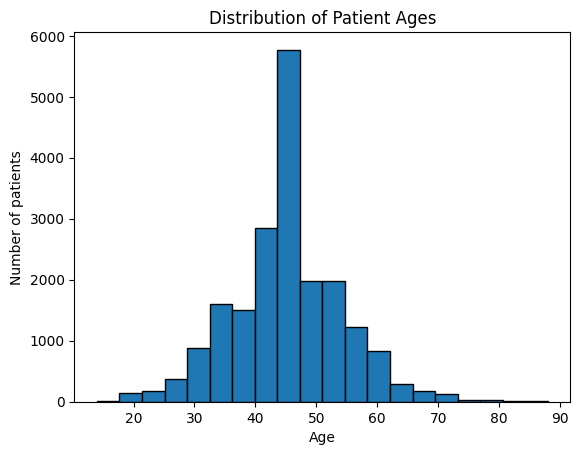

In [27]:
import matplotlib.pyplot as plt

plt.hist(merged_df["Patient's Age"], bins=20, edgecolor='k')
plt.xlabel("Age")
plt.ylabel("Number of patients")
plt.title("Distribution of Patient Ages")
plt.show()


In [28]:
skewness = merged_df["Patient's Age"].skew()
print(f"Skewness: {skewness:.2f}")


Skewness: 0.21


In [29]:
age_bins = [20, 30, 40, 50, 60, 70, 80, 90]
age_labels = ['20-29','30-39','40-49','50-59','60-69','70-79','80-89']
merged_df['Age Group'] = pd.cut(merged_df["Patient's Age"], bins=age_bins, labels=age_labels, right=False)

# Count patients per group
print(merged_df['Age Group'].value_counts().sort_index())

Age Group
20-29     720
30-39    3840
40-49    9980
50-59    4024
60-69    1092
70-79     176
80-89      28
Name: count, dtype: int64


In [30]:
merged_df.columns

Index(['study_id', 'series_id', 'image_id', 'laterality', 'view_position',
       'height', 'width', 'breast_birads', 'breast_density', 'split',
       'Series Instance UID', 'Patient's Age', 'View Position',
       'Image Laterality', 'Photometric Interpretation', 'Rows', 'Columns',
       'Imager Pixel Spacing', 'Pixel Spacing', 'Pixel Padding Value',
       'Pixel Padding Range Limit', 'Window Center', 'Window Width',
       'Rescale Intercept', 'Rescale Slope', 'Rescale Type',
       'Window Center & Width Explanation', 'Manufacturer',
       'Manufacturer's Model Name', 'Age Group'],
      dtype='object')

In [31]:
merged_df.shape

(20000, 30)

In [32]:
merged_df['breast_density'].dtype

dtype('O')

In [33]:
merged_df['breast_density'].isna().sum()

np.int64(0)

In [34]:
merged_df['breast_density'].isna().any()

np.False_

In [35]:
merged_df['breast_density'].unique()

array(['DENSITY C', 'DENSITY B', 'DENSITY D', 'DENSITY A'], dtype=object)

In [36]:
merged_df['breast_density'].value_counts(dropna=False)


,count
breast_density,
DENSITY C,15292
DENSITY D,2700
DENSITY B,1908
DENSITY A,100


In [37]:
percent = merged_df['breast_density'].value_counts(normalize=True, dropna=False) * 100
print(percent)

breast_density
DENSITY C    76.46
DENSITY D    13.50
DENSITY B     9.54
DENSITY A     0.50
Name: proportion, dtype: float64


In [38]:
merged_df['split'].isna().any()

np.False_

In [39]:
merged_df['split'].isna().sum()

np.int64(0)

In [40]:
merged_df['split'].unique()

array(['training', 'test'], dtype=object)

In [41]:
merged_df['split'].value_counts(dropna=False)

,count
split,
training,16000
test,4000


In [44]:
import zipfile
import pandas as pd

zip_path = "/content/drive/MyDrive/VinDr_mammo.png/images_png.zip"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    # List all PNG files
    image_files = [f for f in zip_ref.namelist() if f.endswith(".png")]

# Example: see first 5 files
print(image_files[:5])


['0025a5dc99fd5c742026f0b2b030d3e9/2ddfad7286c2b016931ceccd1e2c7bbc.png', '0025a5dc99fd5c742026f0b2b030d3e9/451562831387e2822923204cf8f0873e.png', '0025a5dc99fd5c742026f0b2b030d3e9/47c8858666bcce92bcbd57974b5ce522.png', '0025a5dc99fd5c742026f0b2b030d3e9/fcf12c2803ba8dc564bf1287c0c97d9a.png', '0028fb2c7f0b3a5cb9a80cb0e1cdbb91/16e58fc1d65fa7587247e6224ee96527.png']


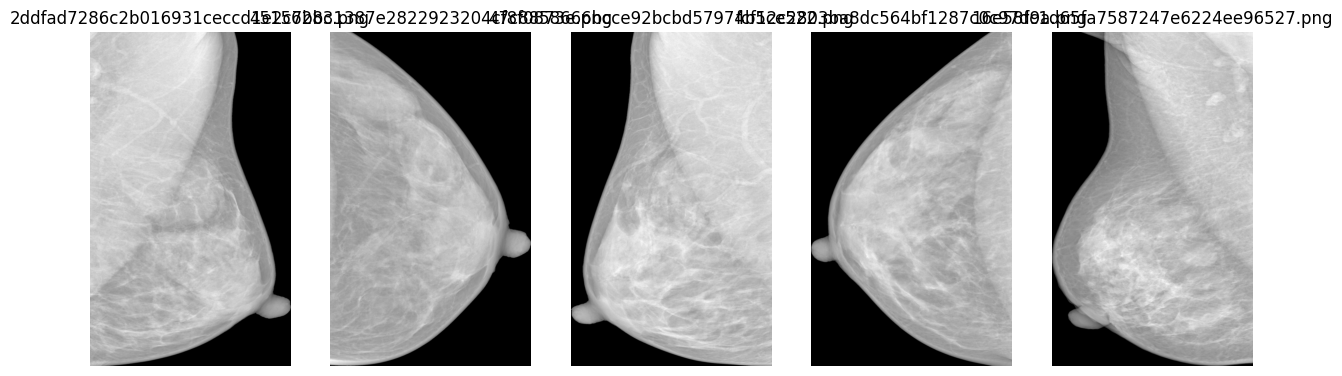

In [46]:
# Show first 5 images
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    plt.figure(figsize=(15, 5))
    for i, f in enumerate(image_files[:5]):
        img = Image.open(zip_ref.open(f))
        plt.subplot(1, 5, i+1)
        plt.imshow(img, cmap='gray')
        plt.title(f.split('/')[-1])  # show filename
        plt.axis('off')
    plt.show()

In [48]:
import zipfile

zip_path = "/content/drive/MyDrive/VinDr_mammo.png/images_png.zip"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    # List first 20 files in the ZIP to see folder structure and names
    all_files = zip_ref.namelist()
    print(all_files[:20])


['0025a5dc99fd5c742026f0b2b030d3e9/2ddfad7286c2b016931ceccd1e2c7bbc.png', '0025a5dc99fd5c742026f0b2b030d3e9/451562831387e2822923204cf8f0873e.png', '0025a5dc99fd5c742026f0b2b030d3e9/47c8858666bcce92bcbd57974b5ce522.png', '0025a5dc99fd5c742026f0b2b030d3e9/fcf12c2803ba8dc564bf1287c0c97d9a.png', '0028fb2c7f0b3a5cb9a80cb0e1cdbb91/16e58fc1d65fa7587247e6224ee96527.png', '0028fb2c7f0b3a5cb9a80cb0e1cdbb91/3704f91985dcbc69f6ac2803523d1ecb.png', '0028fb2c7f0b3a5cb9a80cb0e1cdbb91/7fc1f1bb8bb1a7efaf7104e49c4d8b86.png', '0028fb2c7f0b3a5cb9a80cb0e1cdbb91/c4ce68631bf70949570ded31a3c69e60.png', '0034765af074f93ed33d5e8399355caf/2aca993b3b6e2a32dddd170b00fd5e7d.png', '0034765af074f93ed33d5e8399355caf/68f09c18925a66ef2840d4a62f237b31.png', '0034765af074f93ed33d5e8399355caf/b664cf1e7c968896144a3a2005cd3eb4.png', '0034765af074f93ed33d5e8399355caf/d39964544666ed08df9aa1e9e18d1262.png', '003700f3c960e0b9bca2b8437c3dbf05/17c3d032d611eb3d1baf3434d62483a1.png', '003700f3c960e0b9bca2b8437c3dbf05/3944b33b99c98e76

In [49]:
import pandas as pd

image_data = []
for f in image_files:
    study_id, image_file = f.split('/')  # split folder and file
    image_id = image_file.replace(".png", "")
    image_data.append({
        "study_id": study_id,
        "image_id": image_id,
        "image_path_in_zip": f
    })

images_df = pd.DataFrame(image_data)
print("Images DF shape:", images_df.shape)
images_df.head()


Images DF shape: (20000, 3)


,study_id,image_id,image_path_in_zip
0,0025a5dc99fd5c742026f0b2b030d3e9,2ddfad7286c2b016931ceccd1e2c7bbc,0025a5dc99fd5c742026f0b2b030d3e9/2ddfad7286c2b...
1,0025a5dc99fd5c742026f0b2b030d3e9,451562831387e2822923204cf8f0873e,0025a5dc99fd5c742026f0b2b030d3e9/451562831387e...
2,0025a5dc99fd5c742026f0b2b030d3e9,47c8858666bcce92bcbd57974b5ce522,0025a5dc99fd5c742026f0b2b030d3e9/47c8858666bcc...
3,0025a5dc99fd5c742026f0b2b030d3e9,fcf12c2803ba8dc564bf1287c0c97d9a,0025a5dc99fd5c742026f0b2b030d3e9/fcf12c2803ba8...
4,0028fb2c7f0b3a5cb9a80cb0e1cdbb91,16e58fc1d65fa7587247e6224ee96527,0028fb2c7f0b3a5cb9a80cb0e1cdbb91/16e58fc1d65fa...


In [50]:
# Ensure the columns are strings
merged_df['study_id'] = merged_df['study_id'].astype(str)
merged_df['image_id'] = merged_df['image_id'].astype(str)
images_df['study_id'] = images_df['study_id'].astype(str)
images_df['image_id'] = images_df['image_id'].astype(str)

# Merge
merged_df_with_images = merged_df.merge(images_df, on=['study_id','image_id'], how='left')
print("Merged DF shape:", merged_df_with_images.shape)
merged_df_with_images.head()


Merged DF shape: (20000, 31)


,study_id,series_id,image_id,laterality,view_position,height,width,breast_birads,breast_density,split,...,Window Center,Window Width,Rescale Intercept,Rescale Slope,Rescale Type,Window Center & Width Explanation,Manufacturer,Manufacturer's Model Name,Age Group,image_path_in_zip
0,b8d273e8601f348d3664778dae0e7e0b,b36517b9cbbcfd286a7ae04f643af97a,d8125545210c08e1b1793a5af6458ee2,L,CC,3518,2800,BI-RADS 2,DENSITY C,training,...,1662,1500,0,1,US,linear LUT,SIEMENS,Mammomat Inspiration,50-59,b8d273e8601f348d3664778dae0e7e0b/d8125545210c0...
1,b8d273e8601f348d3664778dae0e7e0b,b36517b9cbbcfd286a7ae04f643af97a,290c658f4e75a3f83ec78a847414297c,L,MLO,3518,2800,BI-RADS 2,DENSITY C,training,...,1664,1500,0,1,US,linear LUT,SIEMENS,Mammomat Inspiration,50-59,b8d273e8601f348d3664778dae0e7e0b/290c658f4e75a...
2,b8d273e8601f348d3664778dae0e7e0b,b36517b9cbbcfd286a7ae04f643af97a,cd0fc7bc53ac632a11643ac4cc91002a,R,CC,3518,2800,BI-RADS 2,DENSITY C,training,...,1600,1500,0,1,US,linear LUT,SIEMENS,Mammomat Inspiration,50-59,b8d273e8601f348d3664778dae0e7e0b/cd0fc7bc53ac6...
3,b8d273e8601f348d3664778dae0e7e0b,b36517b9cbbcfd286a7ae04f643af97a,71638b1e853799f227492bfb08a01491,R,MLO,3518,2800,BI-RADS 2,DENSITY C,training,...,1654,1500,0,1,US,linear LUT,SIEMENS,Mammomat Inspiration,50-59,b8d273e8601f348d3664778dae0e7e0b/71638b1e85379...
4,8269f5971eaca3e5d3772d1796e6bd7a,d931832a0815df082c085b6e09d20aac,dd9ce3288c0773e006a294188aadba8e,L,CC,3518,2800,BI-RADS 1,DENSITY C,training,...,1580,1500,0,1,US,linear LUT,SIEMENS,Mammomat Inspiration,40-49,8269f5971eaca3e5d3772d1796e6bd7a/dd9ce3288c077...


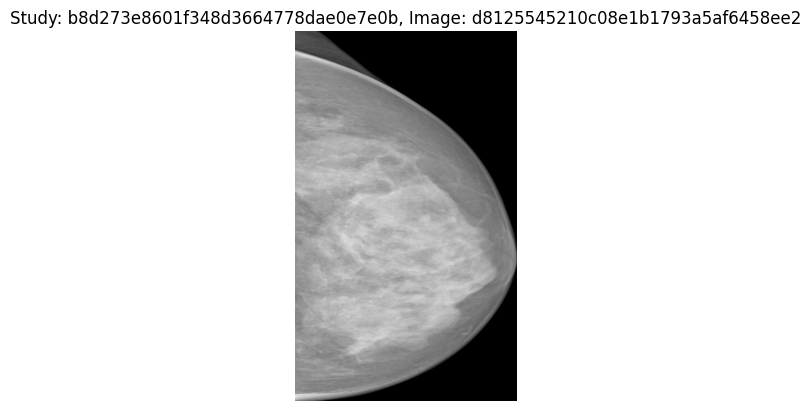

In [51]:
from PIL import Image
import matplotlib.pyplot as plt
import zipfile

sample_row = merged_df_with_images.iloc[0]

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    img = Image.open(zip_ref.open(sample_row['image_path_in_zip']))
    plt.imshow(img, cmap='gray')
    plt.title(f"Study: {sample_row['study_id']}, Image: {sample_row['image_id']}")
    plt.axis('off')
    plt.show()


In [ ]:
!pip install kaggle


In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
!find /content/drive/MyDrive -type f -name "images_png.zip"

In [ ]:
!find /content/drive/MyDrive -type d -name "images_png"


In [ ]:

from google.colab import drive
drive.mount('/content/drive')

!find /content/drive/MyDrive -name "images_png.zip"



Mounted at /content/drive
^C


In [ ]:

!find /content/drive/MyDrive -name "images_png.zip"

^C


In [ ]:
import os

path = "/content/drive/MyDrive"
for root, dirs, files in os.walk(path):
    for file in files:
        if "images_png.zip" in file:
            print(os.path.join(root, file))


KeyboardInterrupt: 

In [ ]:
import os

file_path = "/content/drive/MyDrive/images_png.zip"  # adjust if in subfolder
print(os.path.exists(file_path))


False


In [ ]:
!ls "/content/drive/MyDrive/kaggle_vindr_mammo.png"


images_png.zip	kaggle_vindr_mammo.ipynb


In [ ]:
!unzip -l "/content/drive/MyDrive/kaggle_vindr_mammo/images_png.zip"


unzip:  cannot find or open /content/drive/MyDrive/kaggle_vindr_mammo/images_png.zip, /content/drive/MyDrive/kaggle_vindr_mammo/images_png.zip.zip or /content/drive/MyDrive/kaggle_vindr_mammo/images_png.zip.ZIP.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

!ls "/content/drive/MyDrive/kaggle_vindr_mammo"


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
ls: cannot access '/content/drive/MyDrive/kaggle_vindr_mammo': No such file or directory


In [ ]:
!unzip -l "/content/drive/MyDrive/kaggle_vindr_mammo.png/images_png.zip"


Streaming output truncated to the last 5000 lines.
   336105  2024-06-23 03:30   c11ca2078944ae613d28f33cad6e2975/77177748429714724847c1b77dbb406b.png
   392134  2024-06-23 03:30   c11ca2078944ae613d28f33cad6e2975/d32b5a922b775ce0ef171f5740dd1714.png
   346704  2024-06-23 03:30   c1214fdee190d7f6716962e1ff33cd2f/945d5acf396f4f5fc505898a4bd4bd1d.png
   357817  2024-06-23 03:30   c1214fdee190d7f6716962e1ff33cd2f/b6e83f0c9d498b8775861e134e9b86fb.png
   460567  2024-06-23 03:30   c1214fdee190d7f6716962e1ff33cd2f/d4fe511dee17296827f33d68579556d2.png
   452185  2024-06-23 03:30   c1214fdee190d7f6716962e1ff33cd2f/ec3f673c558fd38bc7cabc9b2692b4d5.png
   454572  2024-06-23 03:30   c12e12f140822510250eb5f7de726c9b/0161d5285a337b2a67dcdec29662b231.png
   366869  2024-06-23 03:30   c12e12f140822510250eb5f7de726c9b/0273181a64f5bbc11d491b19965e31cf.png
   346456  2024-06-23 03:30   c12e12f140822510250eb5f7de726c9b/08163257a305a3b3f16c1da1ed99eefb.png
   484548  2024-06-23 03:30   c12e12f140822510250

AttributeError: module 'matplotlib.pyplot' has no attribute 'ti'

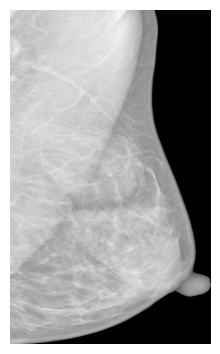

In [ ]:
import zipfile
from PIL import Image
import matplotlib.pyplot as plt
import io

# Path to your zip file
zip_path = "/content/drive/MyDrive/kaggle_vindr_mammo.png/images_png.zip"

# Open the zip file
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    # List the first few image files
    image_files = [f for f in zip_ref.namelist() if f.endswith('.png')][:5]

    plt.figure(figsize=(15,5))
    for i, img_file in enumerate(image_files):
        # Read image from zip
        with zip_ref.open(img_file) as file:
            img = Image.open(file)
            plt.subplot(1, 5, i+1)
            plt.imshow(img, cmap='gray')
            plt.axis('off')
            plt.ti


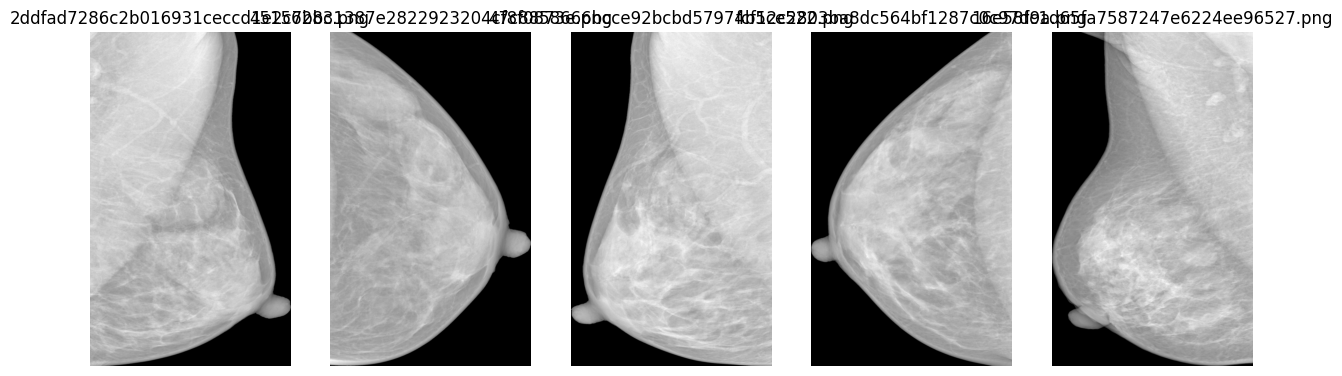

In [ ]:
import zipfile
from PIL import Image
import matplotlib.pyplot as plt
import io

# Path to your zip file
zip_path = "/content/drive/MyDrive/kaggle_vindr_mammo.png/images_png.zip"

# Open the zip file
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    # List the first few image files
    image_files = [f for f in zip_ref.namelist() if f.endswith('.png')][:5]

    plt.figure(figsize=(15,5))
    for i, img_file in enumerate(image_files):
        # Read image from zip
        with zip_ref.open(img_file) as file:
            img = Image.open(file)
            plt.subplot(1, 5, i+1)
            plt.imshow(img, cmap='gray')
            plt.axis('off')
            plt.title(img_file.split('/')[-1])  # <-- fixed this line
    plt.show()
